In [1]:
import torch
from transformer_lens import HookedTransformer

/home/samoilenko/bias-mitigation-interpretability/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
model = HookedTransformer.from_pretrained("gpt2")

`torch_dtype` is deprecated! Use `dtype` instead!


Loaded pretrained model gpt2 into HookedTransformer


In [4]:
clean_tokens = model.to_tokens("When Mary and John went to the store, John gave a drink to")
corrupt_tokens = model.to_tokens("When Mary and John went to the store, Mary gave a drink to")

mary_id = model.to_single_token(" Mary")
john_id = model.to_single_token(" John")

In [13]:
def logit_diff_metric(logits):
    final = logits[:, -1, :]
    return final[:, mary_id] - final[:, john_id]

## Attr patching

In [6]:
with torch.no_grad():
    _, clean_cache = model.run_with_cache(clean_tokens)

In [7]:
corrupt_value_cache, corrupt_grad_cache = {}, {}

In [8]:
def save_activation(act, hook):
    corrupt_value_cache[hook.name] = act.detach()

def save_gradient(grad, hook):
    corrupt_grad_cache[hook.name] = grad.detach()   # this IS ∇_{a_i} L, courtesy of the backward hook


In [10]:
def hook_filter(name):
    return name.endswith("hook_z")

model.reset_hooks()
model.add_hook(hook_filter, save_activation, dir="fwd")
model.add_hook(hook_filter, save_gradient, dir="bwd")

In [14]:
corrupt_logits = model(corrupt_tokens)
metric = logit_diff_metric(corrupt_logits)
metric.backward()          # single backward pass, populates grad for every hook point
model.reset_hooks()

In [15]:
n_layers, n_heads = model.cfg.n_layers, model.cfg.n_heads
attr = torch.zeros(n_layers, n_heads)

In [16]:
for layer in range(n_layers):
    name = f"blocks.{layer}.attn.hook_z"          # [batch, pos, head, d_head]
    diff  = clean_cache[name] - corrupt_value_cache[name]
    grad  = corrupt_grad_cache[name]
    attr[layer] = (grad * diff).sum(dim=(0, 1, 3))  # dot product per head, collapsed to a scalar

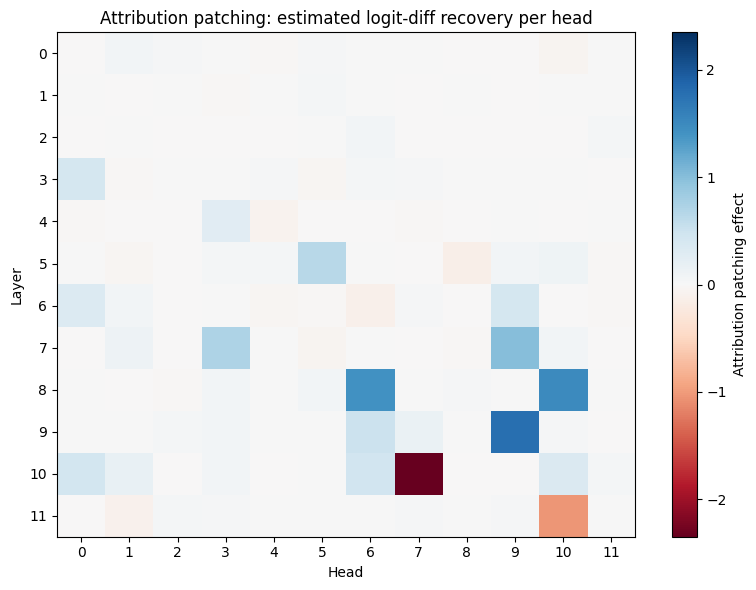

In [18]:
import matplotlib.pyplot as plt
import numpy as np

attr_np = attr.detach().cpu().numpy()  # attr is your [n_layers, n_heads] tensor

fig, ax = plt.subplots(figsize=(8, 6))
vmax = np.abs(attr_np).max()
im = ax.imshow(attr_np, cmap="RdBu", vmin=-vmax, vmax=vmax, aspect="auto")
ax.set_xlabel("Head")
ax.set_ylabel("Layer")
ax.set_xticks(range(attr_np.shape[1]))
ax.set_yticks(range(attr_np.shape[0]))
plt.colorbar(im, label="Attribution patching effect")
plt.title("Attribution patching: estimated logit-diff recovery per head")
plt.tight_layout()
plt.show()

# Act patching

In [5]:
clean_logits, clean_cache = model.run_with_cache(clean_tokens)
corrupt_logits = model(corrupt_tokens)

In [8]:
clean_diff = logit_diff(clean_logits)
corrupt_diff = logit_diff(corrupt_logits)

In [6]:
def patch_resid_pre(activation, hook):
    activation[:, :, :] = clean_cache[hook.name][:, :, :]
    return activation

In [9]:
results = []
for layer in range(model.cfg.n_layers):
    patched_logits = model.run_with_hooks(
        corrupt_tokens,
        fwd_hooks=[(f"blocks.{layer}.hook_resid_pre", patch_resid_pre)],
    )
    patched_diff = logit_diff(patched_logits)
    recovery = (patched_diff - corrupt_diff) / (clean_diff - corrupt_diff)
    results.append(recovery)

In [10]:
results

[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]

In [13]:
def patch_head_z(activation, hook, head_idx):
    activation[:, :, head_idx, :] = clean_cache[hook.name][:, :, head_idx, :]
    return activation

In [14]:
heatmap = torch.zeros(model.cfg.n_layers, model.cfg.n_heads)
for layer in range(model.cfg.n_layers):
    for head in range(model.cfg.n_heads):
        hook_fn = lambda act, hook, h=head: patch_head_z(act, hook, h)
        patched_logits = model.run_with_hooks(
            corrupt_tokens,
            fwd_hooks=[(f"blocks.{layer}.attn.hook_z", hook_fn)],
        )
        recovery = (logit_diff(patched_logits) - corrupt_diff) / (clean_diff - corrupt_diff)
        heatmap[layer, head] = recovery

tensor([[-1.4860e-03,  1.6983e-02,  3.4742e-03,  3.7223e-03,  1.6651e-03,
          8.3181e-03,  4.9739e-04,  4.0644e-04, -2.1166e-03, -1.7822e-03,
         -4.8653e-03,  2.7564e-04],
        [ 2.9932e-04, -8.7476e-04,  2.7433e-05, -3.8842e-03,  2.7221e-04,
          1.0566e-02,  5.2646e-04, -3.1111e-03,  9.4775e-04, -1.9285e-04,
          3.7917e-04,  1.4221e-03],
        [-3.3116e-04,  9.5967e-04, -2.1659e-03, -3.7900e-04, -1.4438e-03,
          2.9850e-04,  1.0171e-02, -2.1208e-03, -1.4352e-03, -1.4879e-03,
         -2.5898e-04,  7.0409e-03],
        [ 1.0213e-01, -3.3328e-03,  6.9514e-04,  3.9598e-04,  3.2794e-03,
         -8.0647e-03,  8.7004e-03,  4.2645e-03,  1.4122e-03,  2.4135e-04,
          2.4412e-03, -6.7717e-04],
        [-3.2794e-03, -2.1522e-03, -3.2920e-04,  5.2791e-02, -1.1632e-02,
         -2.4474e-03, -1.7832e-03, -3.2448e-03, -2.3831e-03,  4.6049e-05,
         -9.2897e-04,  1.4115e-03],
        [ 1.2946e-03, -5.8661e-03, -3.1630e-04,  6.3939e-03,  7.7430e-03,
      

# SAE

from sae_lens import SAE

In [ ]:
model = HookedTransformer.from_pretrained("gpt2")

In [ ]:
sae, cfg_dict, sparsity = SAE.from_pretrained(
    release="gpt2-small-res-jb",        # pretrained GPT-2 Small residual-stream SAEs
    sae_id="blocks.8.hook_resid_pre",   # layer 8
    device="cpu",
)

In [ ]:
tokens = model.to_tokens("The cat sat on the mat")
_, cache = model.run_with_cache(tokens)
resid = cache["blocks.8.hook_resid_pre"]

In [ ]:
feature_acts = sae.encode(resid)              # f(x): [batch, pos, d_sae]
recon = sae.decode(feature_acts)              # x̂

In [ ]:
l0 = (feature_acts > 0).float().sum(-1).mean()
print(f"active features per token: {l0.item():.1f} / {sae.cfg.d_sae}")

In [ ]:
top_vals, top_idx = feature_acts[0, -1].topk(5)
for val, idx in zip(top_vals, top_idx):
    print(f"feature {idx.item()}: {val.item():.2f}")